In [15]:
# Create Data That is Shuffled by a certain lambda
import matplotlib.pyplot as plt
from scipy.signal import convolve
from numpy.linalg import norm
import scipy.io as sio
import numpy as np
import seaborn as sns
import random

np.random.seed(42)
sns.set()

# Use ../ to move up a directory 
mat_data = sio.loadmat('../MatLab Analysis/Data/ExampleDataSet_MonkeyData.mat');

# Extract just a sample of Data for Testing 
sampling_frequency = mat_data['sample_Hz'][0]

# Split the Data into Ground Truth and Predicted
ground_truth = mat_data['SpikeTrains'][:,:,0:25]
pred_correct = mat_data['SpikeTrains'][:,:,26:51]
time_vector = np.arange(1, (ground_truth.shape[1])+1) / sampling_frequency
print(ground_truth.shape)

(12, 1500, 25)


In [16]:
# Lets Create Data where we shuffle based on a lambda
lambda_val = [0, 1, 2, 3, 4, 5, 6, 7 ,8 ,9, 10, 11]
lambda_val = random.sample( lambda_val , len(lambda_val ) )
mat_dim = pred_correct.shape

# Loop through all matrices and all the channels
pred_incorrect = np.zeros(pred_correct.shape)

for mat_id in range(pred_correct.shape[2]):

    # Extract the Channels + Create Storage
    temp_trial = pred_correct[:,:,mat_id];
    pred_incorrect[:, :, mat_id] = temp_trial[lambda_val,:]

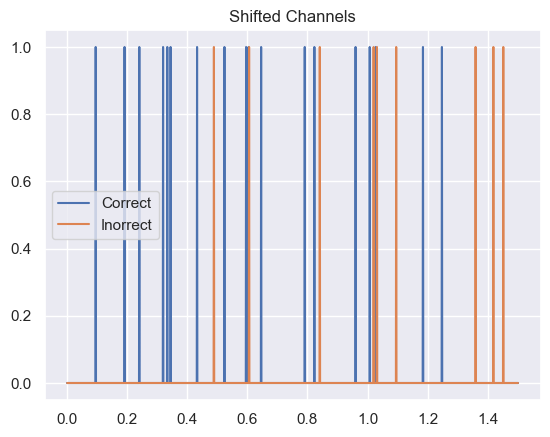

In [18]:
sns.lineplot(x = time_vector, y = pred_correct[1,:,1], label = 'Correct')
sns.lineplot(x = time_vector, y = pred_incorrect[1,:,1],label = 'Inorrect').set(title = 'Shifted Channels')
plt.show()

In [38]:
print(lambda_val)

[1, 10, 2, 0, 8, 6, 7, 3, 4, 9, 5, 11]


In [48]:
# Now lets Test the Function
neuron_id = 6;
van_rossum_correct = np.zeros((1,25));
van_rossum_incorrect = np.zeros((1,25));

schrieber_sim_correct = np.zeros((1,25));
schrieber_sim_incorrect = np.zeros((1,25));

vpupura_correct = np.zeros((1,25));
vpupura_incorrect = np.zeros((1,25));

In [49]:
for mat_id in range(pred_correct.shape[2]):

    # Van Rossum Metric
    tau = 0.01
    spike_true = ground_truth[neuron_id, :, mat_id]
    spike_correct = pred_correct[neuron_id, :, mat_id]
    spike_incorrect = pred_incorrect[neuron_id, :, mat_id]
    
    van_rossum_correct[0, mat_id] = calculate_van_rossum_distance(spike_true, spike_correct, tau, sampling_frequency).item()
    van_rossum_incorrect[0, mat_id] = calculate_van_rossum_distance(spike_true, spike_incorrect, tau, sampling_frequency).item()

    # Schrieber Similarity Metric
    sigma = 0.005
    schrieber_sim_correct[0, mat_id] = calculate_schrieber_similarity(spike_true, spike_correct, sigma, sampling_frequency)
    schrieber_sim_incorrect[0, mat_id] = calculate_schrieber_similarity(spike_true, spike_incorrect, sigma, sampling_frequency)

    # Victor Purpura Metric
    q = 1
    vpupura_correct[0, mat_id] = calculate_victor_purpura(spike_true, spike_correct, q, sampling_frequency)
    vpupura_incorrect[0, mat_id] = calculate_victor_purpura(spike_true, spike_incorrect, q, sampling_frequency)

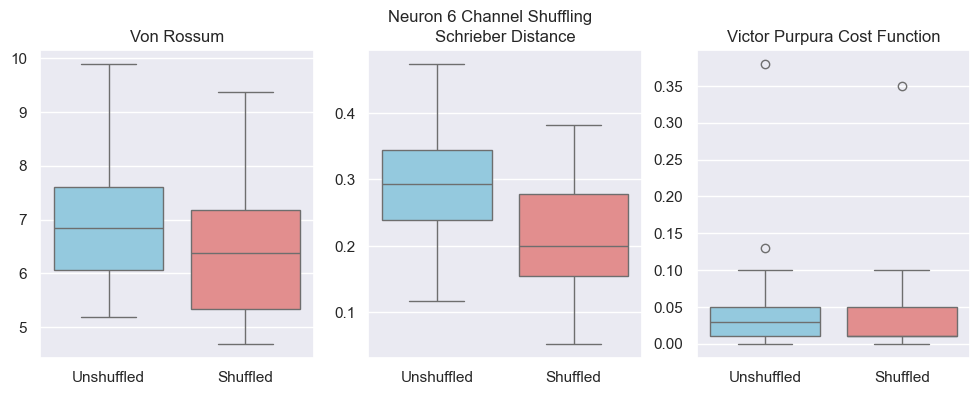

In [50]:
# Terrible Boxplot but I will fix later hehe
colors = ['skyblue', 'lightcoral']

fig, axes = plt.subplots(1,3, figsize = (12,4))
sns.boxplot(ax = axes[0],data = [van_rossum_correct[0], van_rossum_incorrect[0]], palette = colors, ).set(title = 'Von Rossum');
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Unshuffled','Shuffled']);

sns.boxplot(ax = axes[1],data = [schrieber_sim_correct[0], schrieber_sim_incorrect[0]], palette = colors).set(title = 'Schrieber Distance');
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Unshuffled','Shuffled']);

sns.boxplot(ax = axes[2],data = [vpupura_correct[0], vpupura_incorrect[0]], palette = colors).set(title = 'Victor Purpura Cost Function');
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Unshuffled','Shuffled']);

plt.suptitle(f"Neuron {neuron_id} Channel Shuffling", fontsize=12)
plt.show()

In [23]:
# Function for Calculation Van Rossum
def calculate_van_rossum_distance(spike_train_a, spike_train_b, tau, fs):

    # Create the Kernel
    dt = 1 / fs
    kernel_length = (5 * tau / dt).astype(int)[0] # how much of the exponential we are extracting so it is not infinite
    kernel_time = np.arange(0, kernel_length) * dt
    kernel = np.exp(-kernel_time / tau)

    # Ensure we use full to avoid temporal misalignment
    convolve_train_1 = convolve(spike_train_a, kernel, mode = 'full')[:len(time_vector)]
    convolve_train_2 = convolve(spike_train_b, kernel, mode = 'full')[:len(time_vector)]

    # Return Von - Rosssum
    von_rossum_squared = (dt/tau) * np.sum((convolve_train_1 - convolve_train_2)**2)
    von_rossum = np.sqrt(von_rossum_squared)
    return(von_rossum)

In [24]:
# Calculate Schrieber Similarity
def calculate_schrieber_similarity(spike_train_a, spike_train_b, sigma, fs):
    
    # Lets Create a Gaussian to Convolve our signal with 
    dt = 1 / fs
    kernel_size = (6 * sigma / dt).astype(int)[0] # 6 ensures we are covering +/- 3 standard deviations

    # Check if kernel is odd so either side of gaussian is event
    if kernel_size % 2 == 0:
        kernel_size += 1
    
    # Kernel time vector
    kernel_t = np.linspace(-3 * sigma, 3 * sigma, kernel_size) 
    gaussian_kernel = (1 / (np.sqrt(2 * np.pi) * sigma) ) * np.exp(-kernel_t**2 / (2 * sigma**2))

    # Same is possible here due to symmetric gaussian
    convolve_train_1 = convolve(spike_train_a, gaussian_kernel, mode = 'same')
    convolve_train_2 = convolve(spike_train_b, gaussian_kernel, mode = 'same')
    cosine_similarity = np.dot(convolve_train_1, convolve_train_2) / (norm(convolve_train_1) * norm(convolve_train_2))
    return(cosine_similarity)

In [25]:
def calculate_victor_purpura(spike_train_a, spike_train_b, q, fs):
    
    # Compute the Time Vector given the sampling frequency
    time_vector = np.arange(1, len(spike_train_a)+1) / fs

    # Extract the times when a spike occured
    spike_times_a = time_vector[spike_train_a == 1]
    spike_times_b = time_vector[spike_train_b == 1]

    # Determine length or # of spikes
    n = len(spike_times_a)
    m = len(spike_times_b)
    
    # Initiate the cost matrix 
    cost_matrix = np.zeros((n+1,m+1))
    
    # Identify the # of spikes
    cost_matrix[:, 0] = range(0, n+1)
    cost_matrix[0, :] = range(0, m+1)
    
    # Loop through the cost matrix 
    for i in range(1, n+1):
        for j in range(1, m+1):
    
            # 1. Compute the cost shift - identify the time difference between first two spikes 
            # if the difference is large penalize it with a q factor 
            cost_shift = round(q * abs(spike_times_a[i - 1] - spike_times_b[j - 1]),2) 
    
            # 2. Insert B or Delete A - compute corresponding cost
            delete_A = round(cost_matrix[ i - 1, j] + 1,2)
            insert_B = round(cost_matrix [ i , j - 1] + 1,2)
    
            # 3. Identify the minimum cost 
            cost_matrix[i, j] = min(delete_A, insert_B, cost_shift) 

    return(cost_matrix[n,m])